In [1]:
import torch
from transformers import AutoModel, AutoProcessor
from loguru import logger

if not torch.cuda.is_available():
    raise OSError("No cuda available!")
logger.info("Cuda is available!")


model_id = "jinaai/jina-embeddings-v5-omni-nano"
model = AutoModel.from_pretrained(model_id, trust_remote_code=True, default_task="retrieval").eval().to("cuda")
processor = AutoProcessor.from_pretrained(model_id, trust_remote_code=True)

2026-06-28 17:55:04.956 | INFO     | __main__:<module>:7 - Cuda is available!
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/780 [00:00<?, ?it/s]

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

In [2]:
from pathlib import Path

data = Path("./data")

images = [p for p in data.glob("*.jpg")]

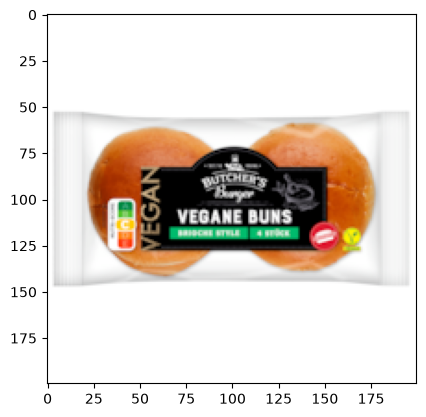

In [4]:
from PIL import Image
import matplotlib.pyplot as plt

example = Image.open(images[0])

plt.imshow(example)
plt.show()

In [5]:
img_embedding = model.embed(**processor(example, text="<image>", return_tensors="pt").to(model.device))

In [8]:
img_embedding.size()

torch.Size([1, 768])

### Image @ Text

In [24]:
vegan_buns = model.embed(**processor(text="Query: Vegane Buns", return_tensors="pt").to(model.device))
burger_buns = model.embed(**processor(text="Query: Burger Buns", return_tensors="pt").to(model.device))
shampoo = model.embed(**processor(text="Query: Shampoo", return_tensors="pt").to(model.device))
ball = model.embed(**processor(text="Query: Ball", return_tensors="pt").to(model.device))

In [25]:
print(f"Vegane Buns: {(vegan_buns @ img_embedding.T).item()}")
print(f"Burger Buns: {(burger_buns @ img_embedding.T).item()}")
print(f"Shampoo: {(shampoo @ img_embedding.T).item()}")
print(f"Ball: {(ball @ img_embedding.T).item()}")

Vegane Buns: 0.63671875
Burger Buns: 0.55078125
Shampoo: 0.146484375
Ball: 0.140625


### Image @ Image

In [26]:
burger_bun = Image.open("./query_images/burger-bun.jpg")
shampoo = Image.open("./query_images/shampoo.jpg")

burger_embedding = model.embed(**processor(burger_bun, text="<image>", return_tensors="pt").to(model.device))
shampoo_embedding = model.embed(**processor(shampoo, text="<image>", return_tensors="pt").to(model.device))

In [27]:
print(f"Burger: {(burger_embedding @ img_embedding.T).item()}")
print(f"Shampoo: {(shampoo_embedding @ img_embedding.T).item()}")

Burger: 0.30078125
Shampoo: 0.2021484375


In [28]:
muffin = Image.open("./query_images/muffin.jpg")
muffin_embedding = model.embed(**processor(muffin, text="<image>", return_tensors="pt").to(model.device))

In [30]:
print(f"Muffin: {(muffin_embedding @ img_embedding.T).item()}")

Muffin: 0.333984375


In [35]:
vegane_buns = Image.open("./query_images/vegane-burger-buns.jpg")
vegane_buns_embedding = model.embed(**processor(vegane_buns, text="<image>", return_tensors="pt").to(model.device))

In [36]:
print(f"Vegane Buns: {(vegane_buns_embedding @ img_embedding.T).item()}")

Vegane Buns: 0.453125
